RQ6 MSE: 2373113.1920654583


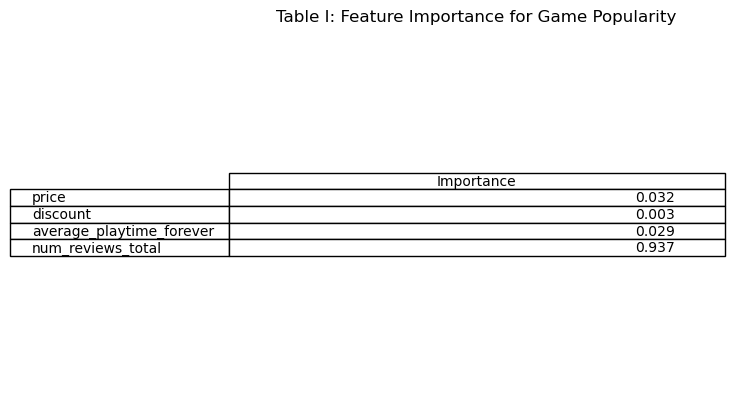

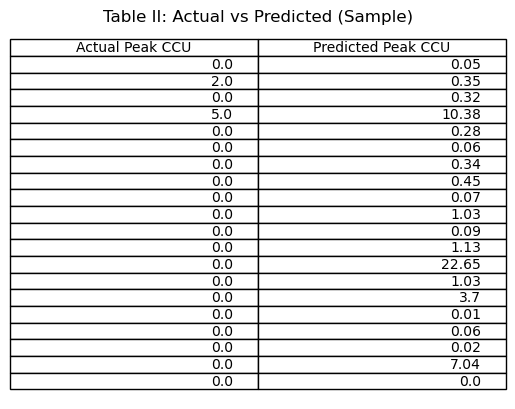

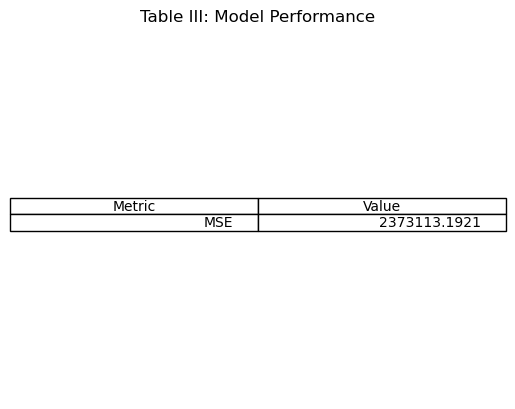

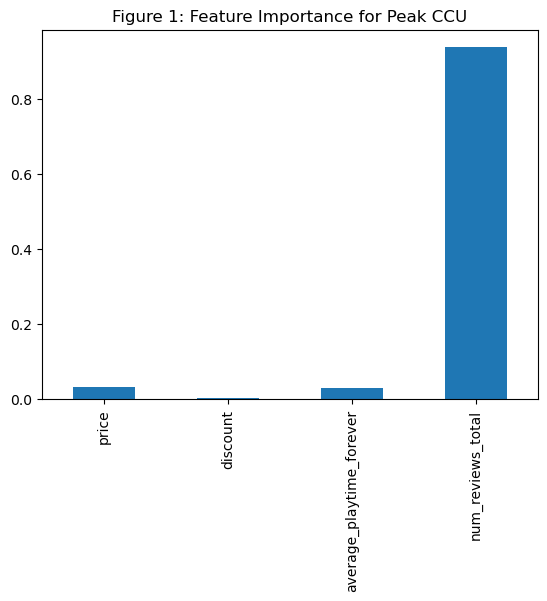

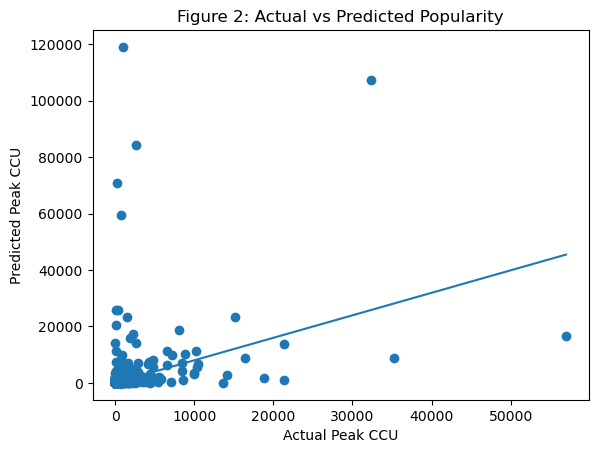

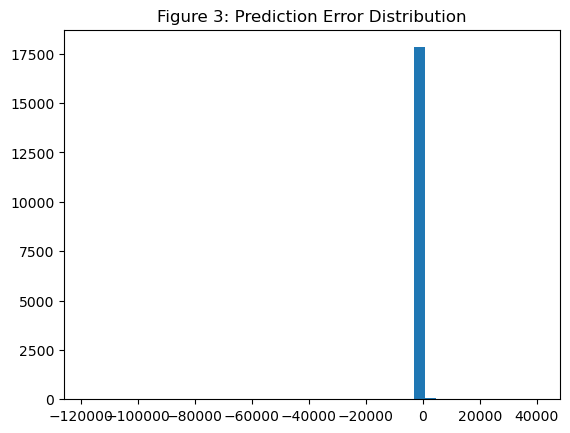

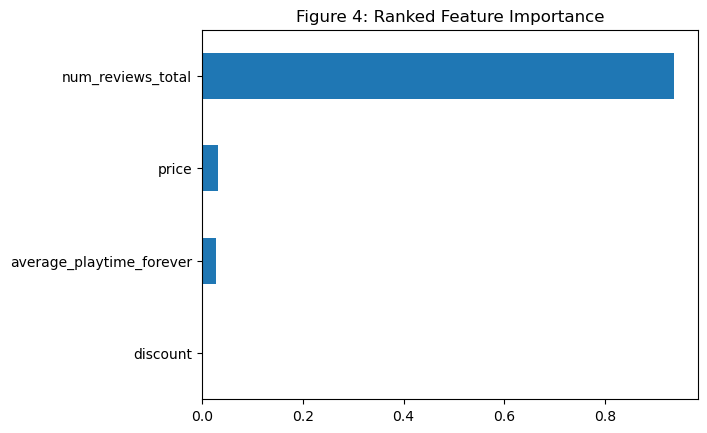

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

import os
os.makedirs('Tables', exist_ok=True)
os.makedirs('Models', exist_ok=True)


# LOAD DATA
df = pd.read_csv(r'games_march2025_cleaned.csv')
df = df.drop_duplicates()


# CLEAN DATA (VERY IMPORTANT)

cols = ['price','discount','average_playtime_forever','num_reviews_total','peak_ccu']

for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

rq6 = df[cols].dropna()


# FEATURE MATRIX

X = rq6[['price','discount','average_playtime_forever','num_reviews_total']]
y = rq6['peak_ccu']


# TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# MODEL

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


# ERROR METRIC

mse = mean_squared_error(y_test, y_pred)
print("RQ6 MSE:", mse)


# TABLE 1: FEATURE IMPORTANCE

importance = pd.Series(model.feature_importances_, index=X.columns)

plt.figure()
plt.axis('off')
plt.table(cellText=np.round(importance.values.reshape(-1,1),3),
          colLabels=['Importance'],
          rowLabels=importance.index,
          loc='center')

plt.title('Table I: Feature Importance for Game Popularity')
plt.savefig('Tables/RQ6_Table1_FeatureImportance.png', dpi=300, bbox_inches='tight')
plt.show()

# TABLE 2: PREDICTION SUMMARY
pred_summary = pd.DataFrame({
    'Actual Peak CCU': y_test.values,
    'Predicted Peak CCU': y_pred
}).head(20)

plt.figure()
plt.axis('off')
plt.table(cellText=np.round(pred_summary.values,2),
          colLabels=pred_summary.columns,
          loc='center')

plt.title('Table II: Actual vs Predicted (Sample)')
plt.savefig('Tables/RQ6_Table2_Predictions.png', dpi=300, bbox_inches='tight')
plt.show()


# TABLE 3: MODEL PERFORMANCE
metrics = pd.DataFrame({
    'Metric': ['MSE'],
    'Value': [mse]
})

# Convert safely (prevents TypeError)
metrics_display = metrics.copy()
metrics_display['Value'] = pd.to_numeric(metrics_display['Value'], errors='coerce').round(4)

plt.figure()
plt.axis('off')

plt.table(
    cellText=metrics_display.values,
    colLabels=metrics_display.columns,
    loc='center'
)

plt.title('Table III: Model Performance')
plt.savefig('Tables/RQ6_Table3_Metrics.png', dpi=300, bbox_inches='tight')
plt.show()
# FIGURE 1: FEATURE IMPORTANCE

plt.figure()
importance.plot(kind='bar')
plt.title('Figure 1: Feature Importance for Peak CCU')
plt.savefig('Models/RQ6_Fig1_Importance.png', dpi=300, bbox_inches='tight')
plt.show()
# FIGURE 2: ACTUAL vs PREDICTED

plt.figure()

plt.scatter(y_test, y_pred)
plt.xlabel('Actual Peak CCU')
plt.ylabel('Predicted Peak CCU')
plt.title('Figure 2: Actual vs Predicted Popularity')

# Safe regression line
z = np.polyfit(np.array(y_test), np.array(y_pred), 1)
p = np.poly1d(z)

x_sorted = np.sort(np.array(y_test))
plt.plot(x_sorted, p(x_sorted))

plt.savefig('Models/RQ6_Fig2_Actual_vs_Predicted.png', dpi=300, bbox_inches='tight')
plt.show()
# FIGURE 3: ERROR DISTRIBUTION
errors = np.array(y_test) - np.array(y_pred)

plt.figure()
plt.hist(errors, bins=40)
plt.title('Figure 3: Prediction Error Distribution')
plt.savefig('Models/RQ6_Fig3_ErrorDistribution.png', dpi=300, bbox_inches='tight')
plt.show()
# FIGURE 4: RANKED FEATURE IMPORTANCE


plt.figure()
importance.sort_values().plot(kind='barh')
plt.title('Figure 4: Ranked Feature Importance')
plt.savefig('Models/RQ6_Fig4_RankedImportance.png', dpi=300, bbox_inches='tight')
plt.show()

